# Import & Helpers

In [2]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from importlib import reload

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")
if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
from noninteracting import KagomeNagaosa
import interaction
import frg_kernel
import channels
import frg_flow
import patching
from patching import build_exactM_patchset, PatchPoint, PatchSet, plot_patchset, exact_M6_points_1bz

## Plot Helper

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import channels
import instability
import frg_flow
import interaction
import frg_kernel

from channels import SZ0ChannelBuilder
from instability import InstabilityConfig, diagnose_kernel_collection
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from frg_kernel import FlowConfig


# ============================================================
# Basic formatting / plotting helpers
# ============================================================

CHANNELS_ORDER = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    """
    Same logic as current solver sign-aware score:
      pp -> largest positive eigenvalue of Hermitian part
      ph -> absolute value of most negative eigenvalue of Hermitian part
    """
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals)) if evals.size else 0.0
    eval_neg_min = float(np.min(evals)) if evals.size else 0.0

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def build_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return channels.SZ0ChannelBuilder.from_solver(
        solver.current_vertex_accessor(),
        solver,
        Landau_F=Landau_F,
    )


def evaluate_signaware_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)
        kernel_store[iq] = {"Q": Q.copy(), "kernels": kernel_dict}

        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })

    df = pd.DataFrame(rows)
    return df, kernel_store


def evaluate_instability_selected_Qs(
    builder,
    solver,
    diagnosis_Qs,
    *,
    temperature=None,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    rows = []
    result_store = {}

    if temperature is None:
        temperature = float(solver.state.T)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # IMPORTANT: keep diagnosis consistent with current flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    for iq, Q in enumerate(diagnosis_Qs):
        Q = np.asarray(Q, dtype=float)
        kernel_dict = builder.build_kernel_dict(Q, Landau_F=landau_F)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": Q.copy(), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": Q.copy(),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store


def leading_row_from_df(df, score_col):
    if len(df) == 0:
        raise ValueError("Empty dataframe.")
    return df.sort_values(score_col, ascending=False).iloc[0]


def plot_channel_bars(df, *, value_col, title, ylabel):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(CHANNELS_ORDER):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0][value_col]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Flow Helper

In [30]:
# ============================================================
# Helpers: time-series of template projection over selected steps
#   RIGHT PANEL uses sector-resolved overlaps:
#   FM  -> overlap with leading eigvec of (Q=0, ph_spin)
#   PI  -> overlap with leading eigvec of (Q=0, ph_charge)
#   cBO -> overlap with leading eigvec of (Q=M, ph_charge)
#   sBO -> overlap with leading eigvec of (Q=M, ph_spin)
# ============================================================

def _resolve_record_and_snapshot_by_step_index(history, snapshots, step_index):
    step_index = int(step_index)

    rec = None
    for r in history:
        if int(r.step_index) == step_index:
            rec = r
            break
    if rec is None:
        raise KeyError(f"Could not find history record for step_index={step_index}")

    if isinstance(snapshots, dict):
        if step_index not in snapshots:
            raise KeyError(f"Could not find snapshot for step_index={step_index}")
        snap = snapshots[step_index]
    else:
        idx = next(i for i, r in enumerate(history) if int(r.step_index) == step_index)
        snap = snapshots[idx]

    return rec, snap


def _choose_QM_for_snapshot(
    solver,
    snapshot,
    QM_list,
    instability_cfg,
    *,
    M_TEMPLATE_CHOICE="best",
    Landau_F_for_channel_build=False,
):
    """
    Pick the finite-Q used for cBO / sBO at one snapshot.

    If M_TEMPLATE_CHOICE == "best", choose the Q in QM_list whose
    max(ph_charge, ph_spin) true-leading score is largest.
    Otherwise interpret it as an explicit index into QM_list.
    """
    if M_TEMPLATE_CHOICE == "best":
        best_score = None
        Q_best = None
        best_pack = None

        for Qm in QM_list:
            kdict_m, idict_m = _build_kernel_and_instability_dict(
                solver,
                Qm,
                instability_cfg,
                snapshot=snapshot,
                Landau_F_for_channel_build=Landau_F_for_channel_build,
            )
            score_c = float(idict_m["ph_charge"].score_unprojected)
            score_s = float(idict_m["ph_spin"].score_unprojected)
            score = max(score_c, score_s)

            if (best_score is None) or (score > best_score):
                best_score = score
                Q_best = np.asarray(Qm, dtype=float)
                best_pack = (kdict_m, idict_m)

        return Q_best, best_pack[0], best_pack[1]

    Q_M = np.asarray(QM_list[int(M_TEMPLATE_CHOICE)], dtype=float)
    kdict_M, idict_M = _build_kernel_and_instability_dict(
        solver,
        Q_M,
        instability_cfg,
        snapshot=snapshot,
        Landau_F_for_channel_build=Landau_F_for_channel_build,
    )
    return Q_M, kdict_M, idict_M


def _sector_overlap_with_template(leading_vec, template_vec):
    """
    Sector-resolved overlap:
      overlap between the template and the leading eigenvector
      of THAT sector/channel itself.
    """
    return _overlap2(template_vec, leading_vec)


def collect_projected_mode_timeseries(
    solver,
    history,
    snapshots,
    *,
    diagnosis_Qs=None,
    last_n_steps=20,
    M_TEMPLATE_CHOICE="best",
    USE_BUBBLE_DRESSED_OPERATOR=True,
    Landau_F_FOR_CHANNEL_BUILD=False,
):
    """
    Collect time series for FM / PI / cBO / sBO over the last n steps.

    Returns a DataFrame with columns:
      step_index, T, Q_M_used_for_cBO_sBO,
      <mode>_projected_score, <mode>_true_leading_score, <mode>_overlap

    Important:
      overlap is now SECTOR-RESOLVED, not overlap with a single global leader.
    """
    if diagnosis_Qs is None:
        if getattr(solver, "diagnosis_Qs", None) is None:
            raise ValueError("diagnosis_Qs not provided and solver.diagnosis_Qs is None.")
        diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]
    else:
        diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]

    Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
    QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

    if len(Q0_list) != 1:
        raise ValueError(f"Expected exactly one Q=0 in diagnosis_Qs, found {len(Q0_list)}")
    if len(QM_list) == 0:
        raise ValueError("Need at least one finite-Q candidate in diagnosis_Qs.")

    Q0 = Q0_list[0]

    instability_cfg = _default_instability_config_from_solver(solver)
    patchset_up = solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]

    templates = _build_harmonic_templates_from_patchset(patchset_up)
    template_FM = templates["FM_L0"]
    basis_P = templates["P_L1_basis"]
    basis_D = templates["D_L2_basis"]

    recs = list(history)
    if len(recs) == 0:
        raise ValueError("history is empty.")

    selected_recs = recs[-int(last_n_steps):]

    rows = []

    for rec in selected_recs:
        step_index = int(rec.step_index)
        _, snap = _resolve_record_and_snapshot_by_step_index(history, snapshots, step_index)

        # -------------------------
        # Q=0 sectors
        # -------------------------
        kdict_Q0, idict_Q0 = _build_kernel_and_instability_dict(
            solver,
            Q0,
            instability_cfg,
            snapshot=snap,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # -------------------------
        # finite-Q sectors
        # -------------------------
        Q_M, kdict_M, idict_M = _choose_QM_for_snapshot(
            solver,
            snap,
            QM_list,
            instability_cfg,
            M_TEMPLATE_CHOICE=M_TEMPLATE_CHOICE,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # =====================================================
        # FM  : (Q=0, ph_spin), template = L0
        # =====================================================
        fm_eval = _evaluate_template_component(
            solver,
            Q0,
            "ph_spin",
            template_FM,
            instability_cfg,
            snapshot=snap,
            use_operator=USE_BUBBLE_DRESSED_OPERATOR,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        FM_sector_lead = _normalize_vec(idict_Q0["ph_spin"].leading_evec)
        FM_overlap = _sector_overlap_with_template(FM_sector_lead, template_FM)

        # =====================================================
        # PI  : (Q=0, ph_charge), template = best L2
        # =====================================================
        pi_op = idict_Q0["ph_charge"].operator_unprojected if (
            USE_BUBBLE_DRESSED_OPERATOR and idict_Q0["ph_charge"].operator_unprojected is not None
        ) else _hermitian(kdict_Q0["ph_charge"].matrix)

        PI_projected_score, template_PI = _best_score_in_subspace(pi_op, basis_D)
        PI_true_leading_score = float(idict_Q0["ph_charge"].score_unprojected)

        PI_sector_lead = _normalize_vec(idict_Q0["ph_charge"].leading_evec)
        PI_overlap = _sector_overlap_with_template(PI_sector_lead, template_PI)

        # =====================================================
        # cBO : (Q=M, ph_charge), template = best L1
        # =====================================================
        cbo_op = idict_M["ph_charge"].operator_unprojected if (
            USE_BUBBLE_DRESSED_OPERATOR and idict_M["ph_charge"].operator_unprojected is not None
        ) else _hermitian(kdict_M["ph_charge"].matrix)

        cBO_projected_score, template_cBO = _best_score_in_subspace(cbo_op, basis_P)
        cBO_true_leading_score = float(idict_M["ph_charge"].score_unprojected)

        cBO_sector_lead = _normalize_vec(idict_M["ph_charge"].leading_evec)
        cBO_overlap = _sector_overlap_with_template(cBO_sector_lead, template_cBO)

        # =====================================================
        # sBO : (Q=M, ph_spin), template = best L1
        # =====================================================
        sbo_op = idict_M["ph_spin"].operator_unprojected if (
            USE_BUBBLE_DRESSED_OPERATOR and idict_M["ph_spin"].operator_unprojected is not None
        ) else _hermitian(kdict_M["ph_spin"].matrix)

        sBO_projected_score, template_sBO = _best_score_in_subspace(sbo_op, basis_P)
        sBO_true_leading_score = float(idict_M["ph_spin"].score_unprojected)

        sBO_sector_lead = _normalize_vec(idict_M["ph_spin"].leading_evec)
        sBO_overlap = _sector_overlap_with_template(sBO_sector_lead, template_sBO)

        rows.append({
            "step_index": step_index,
            "T": float(snap.T),
            "Q_M_used_for_cBO_sBO": np.array2string(np.asarray(Q_M, dtype=float), precision=6),

            "FM_projected_score": float(fm_eval["projected_score"]),
            "FM_true_leading_score": float(fm_eval["true_leading_score"]),
            "FM_overlap": float(FM_overlap),

            "PI_projected_score": float(PI_projected_score),
            "PI_true_leading_score": float(PI_true_leading_score),
            "PI_overlap": float(PI_overlap),

            "cBO_projected_score": float(cBO_projected_score),
            "cBO_true_leading_score": float(cBO_true_leading_score),
            "cBO_overlap": float(cBO_overlap),

            "sBO_projected_score": float(sBO_projected_score),
            "sBO_true_leading_score": float(sBO_true_leading_score),
            "sBO_overlap": float(sBO_overlap),
        })

    df = pd.DataFrame(rows).sort_values("step_index").reset_index(drop=True)
    return df


def plot_projected_mode_timeseries(
    df,
    *,
    x_axis="step_index",   # "step_index" or "T"
    title_suffix="",
    plot_all=True
):
    """
    Left panel:
      solid   = true-leading
      dashed  = template-projected

    Right panel:
      sector-resolved overlaps:
        FM  -> overlap(template_FM,  lead eigvec of Q=0 ph_spin)
        PI  -> overlap(template_PI,  lead eigvec of Q=0 ph_charge)
        cBO -> overlap(template_cBO, lead eigvec of Q=M ph_charge)
        sBO -> overlap(template_sBO, lead eigvec of Q=M ph_spin)
    """
    if x_axis not in {"step_index", "T"}:
        raise ValueError("x_axis must be 'step_index' or 'T'.")

    x = df[x_axis].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # -------------------------
    # Left: scores
    # -------------------------
    if plot_all:
        axes[0].plot(x, df["FM_true_leading_score"], marker="o", label="FM true")
    axes[0].plot(x, df["FM_projected_score"], marker="o", linestyle="--", label="FM template")

    if plot_all:
        axes[0].plot(x, df["PI_true_leading_score"], marker="o", label="PI true")
    axes[0].plot(x, df["PI_projected_score"], marker="o", linestyle="--", label="PI template")

    if plot_all:
        axes[0].plot(x, df["cBO_true_leading_score"], marker="o", label="cBO true")
    axes[0].plot(x, df["cBO_projected_score"], marker="o", linestyle="--", label="cBO template")

    if plot_all:
        axes[0].plot(x, df["sBO_true_leading_score"], marker="o", label="sBO true")
    axes[0].plot(x, df["sBO_projected_score"], marker="o", linestyle="--", label="sBO template")

    axes[0].set_title(f"Template-projected vs true-leading scores{title_suffix}")
    axes[0].set_xlabel(x_axis)
    axes[0].set_ylabel("score")
    axes[0].legend(ncol=2, fontsize=9)
    axes[0].set_yscale("log")

    # -------------------------
    # Right: sector-resolved overlaps
    # -------------------------
    axes[1].plot(x, df["FM_overlap"], marker="o", label="FM")
    axes[1].plot(x, df["PI_overlap"], marker="o", label="PI")
    axes[1].plot(x, df["cBO_overlap"], marker="o", label="cBO")
    axes[1].plot(x, df["sBO_overlap"], marker="o", label="sBO")

    axes[1].set_title(f"Sector-resolved template overlap{title_suffix}")
    axes[1].set_xlabel(x_axis)
    axes[1].set_ylabel(r"$|\langle v_{\rm template}|v_{\rm sector\ lead}\rangle|^2$")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    if x_axis == "T":
        axes[0].invert_xaxis()
        axes[1].invert_xaxis()

    plt.tight_layout()
    plt.show()

## Diagnosis Helper

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step selection helpers
# ============================================================
def summarize_eigenvector_against_constant(eigvec):
    v = np.asarray(eigvec, dtype=complex)
    n = len(v)
    v = v / np.linalg.norm(v)

    u_const = np.ones(n, dtype=complex) / np.sqrt(float(n))
    overlap = np.vdot(u_const, v)

    return {
        "eigvec": v,
        "const_vec": u_const,
        "const_overlap_abs": float(np.abs(overlap)),
        "const_overlap_complex": overlap,
    }


def plot_kernel_eigenstate_components(
    kernel_matrix,
    channel_name,
    Q,
    *,
    title_prefix="Kernel eigenstate components",
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)
    info = summarize_eigenvector_against_constant(eigvec)

    v = info["eigvec"]
    u_const = info["const_vec"]
    overlap_abs = info["const_overlap_abs"]

    idx = np.arange(len(v))
    amp = np.abs(v)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    # left: Re / Im vs patch index
    axes[0].plot(idx, np.real(v), marker="o", linewidth=1.5, label="Re(v)")
    axes[0].plot(idx, np.imag(v), marker="s", linewidth=1.5, label="Im(v)")
    axes[0].plot(idx, np.real(u_const), linestyle=":", linewidth=1.5, color="black", label="constant vector")
    axes[0].set_xlabel("patch index")
    axes[0].set_ylabel("component")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n"
        f"|<u_const|v>| = {overlap_abs:.6f}"
    )
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # right: |component|
    axes[1].bar(idx, amp)
    axes[1].set_xlabel("patch index")
    axes[1].set_ylabel("|component|")
    axes[1].set_title("Absolute component weight of leading eigenstate")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n=== leader eigenstate summary ===")
    print("channel            :", channel_name)
    print("Q                  :", fmt_q(Q, nd=6))
    print("selected eigenvalue:", f"{eigval:.12e}")
    print("kernel dimension   :", len(v))
    print("|<u_const|v>|      :", f"{overlap_abs:.12e}")

    return eigval, eigvec, info

def resolve_history_step(history, step_selector=-1):
    """
    step_selector:
      - negative int: Python-style indexing from the end
      - nonnegative int: exact step_index lookup if possible, else positional fallback
    """
    if len(history) == 0:
        raise ValueError("History is empty.")

    if isinstance(step_selector, (int, np.integer)):
        step_selector = int(step_selector)

        # negative -> python indexing
        if step_selector < 0:
            rec = history[step_selector]
            return rec

        # first try exact step_index
        for rec in history:
            if int(rec.step_index) == step_selector:
                return rec

        # fallback: positional
        if 0 <= step_selector < len(history):
            return history[step_selector]

    raise ValueError(f"Could not resolve step_selector={step_selector!r}")


# ============================================================
# Snapshot helpers
# ============================================================

from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray


def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )


def make_snapshot_from_history_record(solver, rec, label=None):
    """
    Build a snapshot from the CURRENT solver state only if the solver is already
    sitting at that record's state. This helper is mostly for the last step.

    For arbitrary historical steps, use stored snapshots if you saved them during flow.
    """
    if label is None:
        label = f"step_{rec.step_index}"
    return make_snapshot_from_solver(solver, label=label)


def make_snapshot_accessor(snapshot, solver):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)
    p4_residual = np.asarray(snapshot.p4_residual, dtype=float)

    closure_tol = getattr(solver, "closure_tol", None)
    drop_inexact_closure = bool(getattr(solver, "drop_inexact_closure", False))

    def closure_is_valid(p1, p2, p3):
        if not drop_inexact_closure:
            return True
        if closure_tol is None:
            return True
        return bool(float(p4_residual[p1, p2, p3]) <= float(closure_tol))

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        if not closure_is_valid(p1, p2, p3):
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])

    return accessor


def make_builder_from_snapshot(snapshot, solver, *, Landau_F=False):
    return channels.SZ0ChannelBuilder.from_solver(
        make_snapshot_accessor(snapshot, solver),
        solver,
        Landau_F=Landau_F,
    )


# ============================================================
# Diagnosis on one snapshot
# ============================================================

def diagnose_snapshot_signaware(snapshot, solver, diagnosis_Qs, *, landau_F=False):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)
    df, kernel_store = evaluate_signaware_selected_Qs(builder, diagnosis_Qs, landau_F=landau_F)
    return df, kernel_store, builder


def diagnose_snapshot_instability(
    snapshot,
    solver,
    diagnosis_Qs,
    *,
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    builder = make_builder_from_snapshot(snapshot, solver, Landau_F=landau_F)

    cfg = instability.InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=False,
        store_all_evals=False,

        # keep consistent with solver flow measure
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", 1e-8),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

    flow_cfg = frg_kernel.FlowConfig(
        temperature=float(snapshot.T),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    rows = []
    result_store = {}

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=landau_F)

        res_dict = instability.diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        result_store[iq] = {"Q": np.asarray(Q, dtype=float), "results": res_dict}

        for ch_name, res in res_dict.items():
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": np.asarray(Q, dtype=float),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    df = pd.DataFrame(rows)
    return df, result_store, builder


# ============================================================
# Eigenvector distribution helpers
# ============================================================

def choose_signaware_eigenpair(channel_name, M):
    H = hermitian_part(M)
    evals, evecs = np.linalg.eigh(H)

    if channel_name.startswith("pp"):
        idx = int(np.argmax(evals))
    elif channel_name.startswith("ph"):
        idx = int(np.argmin(evals))
    else:
        raise ValueError(f"Unknown channel_name={channel_name}")

    val = float(np.real(evals[idx]))
    vec = np.asarray(evecs[:, idx], dtype=complex)
    nrm = np.linalg.norm(vec)
    if nrm > 0:
        vec = vec / nrm
    return val, vec


def plot_kernel_eigenstate_distribution(
    kernel_matrix,
    channel_name,
    Q,
    patchsets,
    *,
    title_prefix="Kernel eigenstate distribution",
    annotate=True,
):
    eigval, eigvec = choose_signaware_eigenpair(channel_name, kernel_matrix)

    ps = patchsets["up"]
    ks = np.asarray([p.k_cart for p in ps.patches], dtype=float)

    amp = np.abs(eigvec)
    phase = np.angle(eigvec)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # amplitude
    sc0 = axes[0].scatter(ks[:, 0], ks[:, 1], c=amp, s=120, cmap="viridis")
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[0].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[0].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\n|evec|"
    )
    axes[0].set_xlabel(r"$k_x$")
    axes[0].set_ylabel(r"$k_y$")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0])

    # phase
    sc1 = axes[1].scatter(ks[:, 0], ks[:, 1], c=phase, s=120, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    if annotate:
        for i, (x, y) in enumerate(ks):
            axes[1].text(x, y, str(i), fontsize=8, ha="left", va="bottom")
    axes[1].set_title(
        f"{title_prefix}\n{channel_name} @ Q={fmt_q(Q)} | chosen eval={eigval:.3e}\nphase(evec)"
    )
    axes[1].set_xlabel(r"$k_x$")
    axes[1].set_ylabel(r"$k_y$")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1])

    plt.tight_layout()
    plt.show()

    return eigval, eigvec


# ============================================================
# High-level one-step diagnosis wrapper
# ============================================================

def diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    *,
    step_selector=-1,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
):
    rec = resolve_history_step(history, step_selector=step_selector)
    if "snapshots" not in globals():
        raise ValueError("No snapshots found. Re-run the flow cell that stores snapshots.")
    
    if int(rec.step_index) not in snapshots:
        raise ValueError(f"Snapshot for step {rec.step_index} not found.")
    
    snapshot = snapshots[int(rec.step_index)]
    print(f"Diagnosing step_index = {rec.step_index}")
    print(f"T = {rec.temperature:.6f}")
    print(f"rhs_norm = {rec.rhs_norm:.3e}")
    print(f"channel_norm = {rec.channel_norm:.3e}")
    print(f"instability = {rec.instability}")
    print(f"terminated_early = {rec.terminated_early}")
    print(f"instability_reason = {rec.instability_reason}")
    print(f"termination_reason = {rec.termination_reason}")

    # sign-aware
    df_sign, sign_store, sign_builder = diagnose_snapshot_signaware(
        snapshot, solver, diagnosis_Qs, landau_F=False
    )

    # instability
    df_inst, inst_store, inst_builder = diagnose_snapshot_instability(
        snapshot,
        solver,
        diagnosis_Qs,
        landau_F=False,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
    )

    # leaders
    best_sign = leading_row_from_df(df_sign, "physical_score")
    best_inst = leading_row_from_df(df_inst, "score")

    print("\n=== sign-aware leader at selected step ===")
    print("channel :", best_sign["channel"])
    print("Q       :", fmt_q(best_sign["Q"], nd=6))
    print("score   :", f"{best_sign['physical_score']:.12e}")
    print("chosen  :", best_sign["chosen_sign"], f"{best_sign['chosen_eval']:.12e}")

    print("\n=== physical-instability leader at selected step ===")
    print("channel :", best_inst["channel"])
    print("Q       :", fmt_q(best_inst["Q"], nd=6))
    print("score   :", f"{best_inst['score']:.12e}")
    print("eval    :", f"{best_inst['leading_eval']:.12e}")
    print("bubble  :", best_inst["bubble_source"])
    print("proj    :", best_inst["projection_name"])

    # plots 1 and 2
    plot_channel_bars(
        df_sign,
        value_col="physical_score",
        title=f"Flowed step {rec.step_index}: sign-aware kernel score on selected Q's",
        ylabel="sign-aware physical score",
    )

    plot_channel_bars(
        df_inst,
        value_col="score",
        title=f"Flowed step {rec.step_index}: physical instability score on selected Q's",
        ylabel="instability score",
    )

    # plot 3: eigenstate distribution of the leading sign-aware kernel
    eig_info = None
    if plot_eigenstate:
        lead_qi = int(best_sign["Q_index"])
        lead_q = np.asarray(best_sign["Q"], dtype=float)
        lead_channel = str(best_sign["channel"])

        lead_kernel = sign_store[lead_qi]["kernels"][lead_channel]
        eigval1, eigvec1 = plot_kernel_eigenstate_distribution(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            solver.patchsets,
            title_prefix=f"Step {rec.step_index}",
            annotate=True,
        )
        
        eigval2, eigvec2, eig_summary = plot_kernel_eigenstate_components(
            lead_kernel.matrix,
            lead_channel,
            lead_q,
            title_prefix=f"Step {rec.step_index}",
        )
        
        eig_info = {
            "channel": lead_channel,
            "Q_index": lead_qi,
            "Q": lead_q,
            "eigval": eigval1,
            "eigvec": eigvec1,
            "summary": eig_summary,
        }

    return {
        "record": rec,
        "snapshot": snapshot,
        "df_signaware": df_sign,
        "df_instability": df_inst,
        "sign_store": sign_store,
        "instability_store": inst_store,
        "eigenstate_info": eig_info,
    }

In [26]:
# ============================================================
# Helpers: analytic-template projected diagnosis on CURRENT or SELECTED snapshot
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from instability import (
    FlowConfig,
    InstabilityConfig,
    diagnose_kernel_collection,
)

# ------------------------------------------------------------
# Basic linear algebra helpers
# ------------------------------------------------------------
def _normalize_vec(v, tol=1e-14):
    v = np.asarray(v, dtype=complex).reshape(-1)
    nrm = np.linalg.norm(v)
    if nrm < tol:
        raise ValueError("Vector norm is too small to normalize.")
    j = int(np.argmax(np.abs(v)))
    phase = np.exp(-1j * np.angle(v[j])) if np.abs(v[j]) > tol else 1.0
    return phase * v / nrm

def _hermitian(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)

def _rayleigh(M, v):
    v = _normalize_vec(v)
    return float(np.real(np.vdot(v, M @ v)))

def _overlap2(v1, v2):
    v1 = _normalize_vec(v1)
    v2 = _normalize_vec(v2)
    return float(np.abs(np.vdot(v1, v2)) ** 2)

def _allclose_zero(q, tol=1e-10):
    q = np.asarray(q, dtype=float)
    return np.allclose(q, 0.0, atol=tol, rtol=0.0)

# ------------------------------------------------------------
# Instability config / channel reconstruction
# ------------------------------------------------------------
def _default_instability_config_from_solver(solver):
    return InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        ph_bubble_mode="patchrep",
        project_ph_charge_q0_uniform=True,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=False,
        store_operator_matrices=True,
        store_all_evals=False,
        patch_measure_mode=getattr(solver, "patch_measure_mode", "unit"),
        patch_measure_soft_vf_eps=getattr(solver, "patch_measure_soft_vf_eps", None),
        patch_measure_normalize_mean=getattr(solver, "patch_measure_normalize_mean", False),
    )

def _build_kernel_and_instability_dict(
    solver,
    Q,
    instability_cfg,
    *,
    snapshot=None,
    Landau_F_for_channel_build=False,
):
    if snapshot is None:
        builder = solver._build_channel_builder()
        T_here = float(solver.state.T)
    else:
        builder = make_builder_from_snapshot(
            snapshot, solver, Landau_F=Landau_F_for_channel_build
        )
        T_here = float(snapshot.T)

    kernel_dict = builder.build_kernel_dict(Q, Landau_F=Landau_F_for_channel_build)

    flow_cfg = FlowConfig(
        temperature=T_here,
        nfreq=int(solver.nfreq),
        include_explicit_T_prefactor=bool(solver.include_explicit_T_prefactor),
    )

    instab_dict = diagnose_kernel_collection(
        kernel_dict,
        solver.patchsets,
        solver.transfer_context(),
        flow_cfg,
        config=instability_cfg,
    )
    return kernel_dict, instab_dict

def _evaluate_template_component(
    solver,
    Q,
    kernel_name,
    template_vec,
    instability_cfg,
    *,
    snapshot=None,
    use_operator=True,
    Landau_F_for_channel_build=False,
):
    kdict, idict = _build_kernel_and_instability_dict(
        solver,
        Q,
        instability_cfg,
        snapshot=snapshot,
        Landau_F_for_channel_build=Landau_F_for_channel_build,
    )

    ker = kdict[kernel_name]
    res = idict[kernel_name]

    H = _hermitian(ker.matrix)
    O = res.operator_unprojected if res.operator_unprojected is not None else None

    if use_operator and (O is not None):
        projected_score = _rayleigh(O, template_vec)
    else:
        projected_score = _rayleigh(H, template_vec)

    current_leader = _normalize_vec(res.leading_evec)
    overlap_leader = _overlap2(template_vec, current_leader)
    true_leading_score = float(res.score_unprojected)

    return {
        "kernel": ker,
        "instability": res,
        "projected_score": float(projected_score),
        "overlap_with_current_leader": float(overlap_leader),
        "true_leading_score": float(true_leading_score),
        "current_leader": current_leader,
        "operator_unprojected": O,
        "hermitian_kernel": H,
    }

def _resolve_snapshot_and_record(history, snapshots, step_selector=-1):
    rec = resolve_history_step(history, step_selector=step_selector)

    if isinstance(snapshots, dict):
        snap = snapshots[int(rec.step_index)]
    else:
        idx = next(i for i, r in enumerate(history) if int(r.step_index) == int(rec.step_index))
        snap = snapshots[idx]

    return rec, snap

# ------------------------------------------------------------
# Patch-angle based analytic harmonic templates
# ------------------------------------------------------------
def _patch_angles_from_patchset(patchset):
    ks = np.array([p.k_cart for p in patchset.patches], dtype=float)
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    return ks, theta

def _orthonormalize_templates(vec_list, tol=1e-12):
    out = []
    for v in vec_list:
        w = np.asarray(v, dtype=complex).reshape(-1).copy()
        for u in out:
            w = w - np.vdot(u, w) * u
        nrm = np.linalg.norm(w)
        if nrm > tol:
            out.append(w / nrm)
    return out

def _real_template_from_basis(basis, coeffs=None):
    if coeffs is None:
        coeffs = np.ones(len(basis), dtype=float)
    v = np.zeros_like(basis[0], dtype=complex)
    for c, b in zip(coeffs, basis):
        v = v + c * b
    return _normalize_vec(np.real_if_close(v))

def _build_harmonic_templates_from_patchset(patchset):
    """
    Returns a dictionary of independent analytic templates.
    These are approximate harmonic templates on the FS loop.
    """
    ks, theta = _patch_angles_from_patchset(patchset)
    N = len(theta)

    # L=0
    fm = np.ones(N, dtype=float)

    # L=1 basis
    p_cos = np.cos(theta)
    p_sin = np.sin(theta)

    # L=2 basis
    d_cos = np.cos(2.0 * theta)
    d_sin = np.sin(2.0 * theta)

    # remove uniform piece and orthonormalize within each sector
    fm_basis = _orthonormalize_templates([fm])
    p_basis = _orthonormalize_templates([p_cos, p_sin])
    d_basis = _orthonormalize_templates([d_cos, d_sin])

    out = {
        "k_cart": ks,
        "theta": theta,
        "FM_L0": fm_basis[0],
        "P_L1_basis": p_basis,
        "D_L2_basis": d_basis,
    }
    return out

def _best_score_in_subspace(M, basis):
    """
    Maximize Rayleigh quotient inside span(basis).
    Returns:
      best_score, best_vec_in_full_space
    """
    basis = [_normalize_vec(b) for b in basis]
    B = np.column_stack(basis)  # N x m
    Msub = B.conjugate().T @ M @ B
    Msub = _hermitian(Msub)
    vals, vecs = np.linalg.eigh(Msub)
    idx = np.argmax(vals)
    best_score = float(np.real(vals[idx]))
    coeff = vecs[:, idx]
    best_vec = B @ coeff
    best_vec = _normalize_vec(best_vec)
    return best_score, best_vec

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def plot_patch_vector_on_loop(patchset, vec, *, title="", ax=None, color_label="Re(component)"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    ks = np.array([p.k_cart for p in patchset.patches], dtype=float)
    v = _normalize_vec(vec)

    sc = ax.scatter(ks[:, 0], ks[:, 1], c=np.real(v), s=120)
    for i, (x, y) in enumerate(ks):
        ax.text(x, y, str(i), fontsize=9, ha="center", va="center")
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, label=color_label)
    return ax

In [27]:
# ============================================================
# Helpers: time-series of template projection over selected steps
# ============================================================

def _resolve_record_and_snapshot_by_step_index(history, snapshots, step_index):
    step_index = int(step_index)

    rec = None
    for r in history:
        if int(r.step_index) == step_index:
            rec = r
            break
    if rec is None:
        raise KeyError(f"Could not find history record for step_index={step_index}")

    if isinstance(snapshots, dict):
        if step_index not in snapshots:
            raise KeyError(f"Could not find snapshot for step_index={step_index}")
        snap = snapshots[step_index]
    else:
        idx = next(i for i, r in enumerate(history) if int(r.step_index) == step_index)
        snap = snapshots[idx]

    return rec, snap


def _choose_QM_for_snapshot(
    solver,
    snapshot,
    QM_list,
    instability_cfg,
    *,
    M_TEMPLATE_CHOICE="best",
    Landau_F_for_channel_build=False,
):
    """
    Pick the finite-Q used for cBO / sBO at one snapshot.

    If M_TEMPLATE_CHOICE == "best", choose the Q in QM_list whose
    max(ph_charge, ph_spin) true-leading score is largest.
    Otherwise interpret it as an explicit index into QM_list.
    """
    if M_TEMPLATE_CHOICE == "best":
        best_score = None
        Q_best = None
        best_pack = None

        for Qm in QM_list:
            kdict_m, idict_m = _build_kernel_and_instability_dict(
                solver,
                Qm,
                instability_cfg,
                snapshot=snapshot,
                Landau_F_for_channel_build=Landau_F_for_channel_build,
            )
            score_c = float(idict_m["ph_charge"].score_unprojected)
            score_s = float(idict_m["ph_spin"].score_unprojected)
            score = max(score_c, score_s)

            if (best_score is None) or (score > best_score):
                best_score = score
                Q_best = np.asarray(Qm, dtype=float)
                best_pack = (kdict_m, idict_m)

        return Q_best, best_pack[0], best_pack[1]

    Q_M = np.asarray(QM_list[int(M_TEMPLATE_CHOICE)], dtype=float)
    kdict_M, idict_M = _build_kernel_and_instability_dict(
        solver,
        Q_M,
        instability_cfg,
        snapshot=snapshot,
        Landau_F_for_channel_build=Landau_F_for_channel_build,
    )
    return Q_M, kdict_M, idict_M


def collect_projected_mode_timeseries(
    solver,
    history,
    snapshots,
    *,
    diagnosis_Qs=None,
    last_n_steps=20,
    M_TEMPLATE_CHOICE="best",
    USE_BUBBLE_DRESSED_OPERATOR=True,
    Landau_F_FOR_CHANNEL_BUILD=False,
):
    """
    Collect time series for FM / PI / cBO / sBO over the last n steps.

    Returns a DataFrame with columns:
      step_index, T, Q_M_used_for_cBO_sBO,
      <mode>_projected_score, <mode>_true_leading_score, <mode>_overlap
    """
    if diagnosis_Qs is None:
        if getattr(solver, "diagnosis_Qs", None) is None:
            raise ValueError("diagnosis_Qs not provided and solver.diagnosis_Qs is None.")
        diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]
    else:
        diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]

    Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
    QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

    if len(Q0_list) != 1:
        raise ValueError(f"Expected exactly one Q=0 in diagnosis_Qs, found {len(Q0_list)}")
    if len(QM_list) == 0:
        raise ValueError("Need at least one finite-Q candidate in diagnosis_Qs.")

    Q0 = Q0_list[0]

    instability_cfg = _default_instability_config_from_solver(solver)
    patchset_up = solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]

    templates = _build_harmonic_templates_from_patchset(patchset_up)
    template_FM = templates["FM_L0"]
    basis_P = templates["P_L1_basis"]
    basis_D = templates["D_L2_basis"]

    recs = list(history)
    if len(recs) == 0:
        raise ValueError("history is empty.")

    selected_recs = recs[-int(last_n_steps):]

    rows = []

    for rec in selected_recs:
        step_index = int(rec.step_index)
        _, snap = _resolve_record_and_snapshot_by_step_index(history, snapshots, step_index)

        # Q=0
        kdict_Q0, idict_Q0 = _build_kernel_and_instability_dict(
            solver,
            Q0,
            instability_cfg,
            snapshot=snap,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # finite-Q
        Q_M, kdict_M, idict_M = _choose_QM_for_snapshot(
            solver,
            snap,
            QM_list,
            instability_cfg,
            M_TEMPLATE_CHOICE=M_TEMPLATE_CHOICE,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # FM
        fm_eval = _evaluate_template_component(
            solver,
            Q0,
            "ph_spin",
            template_FM,
            instability_cfg,
            snapshot=snap,
            use_operator=USE_BUBBLE_DRESSED_OPERATOR,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD,
        )

        # PI
        pi_op = idict_Q0["ph_charge"].operator_unprojected if (
            USE_BUBBLE_DRESSED_OPERATOR and idict_Q0["ph_charge"].operator_unprojected is not None
        ) else _hermitian(kdict_Q0["ph_charge"].matrix)

        PI_projected_score, template_PI = _best_score_in_subspace(pi_op, basis_D)
        PI_overlap = _overlap2(template_PI, idict_Q0["ph_charge"].leading_evec)
        PI_true_leading_score = float(idict_Q0["ph_charge"].score_unprojected)

        # cBO
        cbo_op = idict_M["ph_charge"].operator_unprojected if (
            USE_BUBBLE_DRESSED_OPERATOR and idict_M["ph_charge"].operator_unprojected is not None
        ) else _hermitian(kdict_M["ph_charge"].matrix)

        cBO_projected_score, template_cBO = _best_score_in_subspace(cbo_op, basis_P)
        cBO_overlap = _overlap2(template_cBO, idict_M["ph_charge"].leading_evec)
        cBO_true_leading_score = float(idict_M["ph_charge"].score_unprojected)

        # sBO
        sbo_op = idict_M["ph_spin"].operator_unprojected if (
            USE_BUBBLE_DRESSED_OPERATOR and idict_M["ph_spin"].operator_unprojected is not None
        ) else _hermitian(kdict_M["ph_spin"].matrix)

        sBO_projected_score, template_sBO = _best_score_in_subspace(sbo_op, basis_P)
        sBO_overlap = _overlap2(template_sBO, idict_M["ph_spin"].leading_evec)
        sBO_true_leading_score = float(idict_M["ph_spin"].score_unprojected)

        rows.append({
            "step_index": step_index,
            "T": float(snap.T),
            "Q_M_used_for_cBO_sBO": np.array2string(np.asarray(Q_M, dtype=float), precision=6),

            "FM_projected_score": float(fm_eval["projected_score"]),
            "FM_true_leading_score": float(fm_eval["true_leading_score"]),
            "FM_overlap": float(fm_eval["overlap_with_current_leader"]),

            "PI_projected_score": float(PI_projected_score),
            "PI_true_leading_score": float(PI_true_leading_score),
            "PI_overlap": float(PI_overlap),

            "cBO_projected_score": float(cBO_projected_score),
            "cBO_true_leading_score": float(cBO_true_leading_score),
            "cBO_overlap": float(cBO_overlap),

            "sBO_projected_score": float(sBO_projected_score),
            "sBO_true_leading_score": float(sBO_true_leading_score),
            "sBO_overlap": float(sBO_overlap),
        })

    df = pd.DataFrame(rows).sort_values("step_index").reset_index(drop=True)
    return df


def plot_projected_mode_timeseries(
    df,
    *,
    x_axis="step_index",   # "step_index" or "T"
    title_suffix="",
    plot_all=True
):
    """
    Left panel:
      solid   = true-leading
      dashed  = template-projected

    Right panel:
      overlap
    """
    if x_axis not in {"step_index", "T"}:
        raise ValueError("x_axis must be 'step_index' or 'T'.")

    x = df[x_axis].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # -------------------------
    # Left: scores
    # -------------------------
    if plot_all:
        axes[0].plot(x, df["FM_true_leading_score"], marker="o", label="FM true")
    axes[0].plot(x, df["FM_projected_score"], marker="o", linestyle="--", label="FM template")
    if plot_all:
        axes[0].plot(x, df["PI_true_leading_score"], marker="o", label="PI true")
    axes[0].plot(x, df["PI_projected_score"], marker="o", linestyle="--", label="PI template")
    if plot_all:
        axes[0].plot(x, df["cBO_true_leading_score"], marker="o", label="cBO true")
    axes[0].plot(x, df["cBO_projected_score"], marker="o", linestyle="--", label="cBO template")
    if plot_all:
        axes[0].plot(x, df["sBO_true_leading_score"], marker="o", label="sBO true")
    axes[0].plot(x, df["sBO_projected_score"], marker="o", linestyle="--", label="sBO template")

    axes[0].set_title(f"Template-projected vs true-leading scores{title_suffix}")
    axes[0].set_xlabel(x_axis)
    axes[0].set_ylabel("score")
    axes[0].legend(ncol=2, fontsize=9)
    axes[0].set_yscale("log")
    # -------------------------
    # Right: overlaps
    # -------------------------
    axes[1].plot(x, df["FM_overlap"], marker="o", label="FM")
    axes[1].plot(x, df["PI_overlap"], marker="o", label="PI")
    axes[1].plot(x, df["cBO_overlap"], marker="o", label="cBO")
    axes[1].plot(x, df["sBO_overlap"], marker="o", label="sBO")

    axes[1].set_title(f"Overlap with current leading eigenvector{title_suffix}")
    axes[1].set_xlabel(x_axis)
    axes[1].set_ylabel(r"$|\langle v_{\rm template}|v_{\rm lead}\rangle|^2$")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    # optional: for T-axis, descending temperature often looks more natural
    if x_axis == "T":
        axes[0].invert_xaxis()
        axes[1].invert_xaxis()

    plt.tight_layout()
    plt.show()

# Patch

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

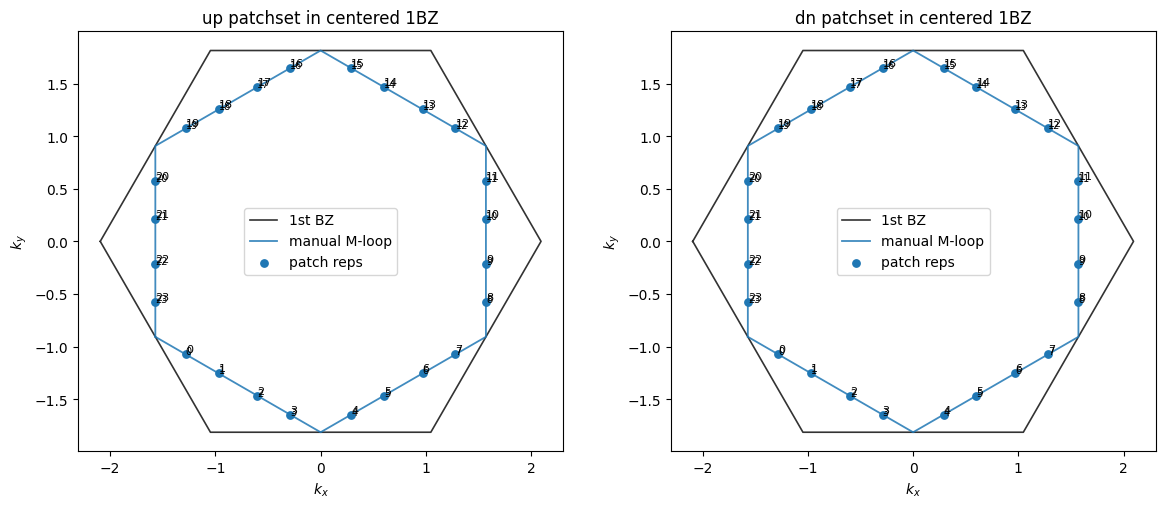

In [8]:
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1
model = KagomeNagaosa(dict(t=1.0, phi=0.0), spin=True, B=None)
# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 5           # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

PATCHSETS = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        # remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        # remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
        project_to_fs_points=True,
        mu=0.0,
        keep_strict_M_anchors=False,
        edge_cluster_alpha=0.9
    ),
}

# ------------------------------------------------------------
# basic sanity: centered 1BZ patch plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    patching.plot_patchset(
        PATCHSETS[spin],
        ax=ax,
        show_contour=True,
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in PATCHSETS[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} patchset in centered 1BZ")

plt.tight_layout()
plt.show()


# Model

CASE = U_only  | U = 5.0  V = 3.5
T_START, T_STOP, NFREQ, NSTEPS = 2.0 0.05 50 600
NPATCH = 24
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 600
initial channel norm    = 6.98672399504442
solver.patch_measure_mode = length_over_vf_soft

=== bare (initial) sign-aware kernel metrics ===


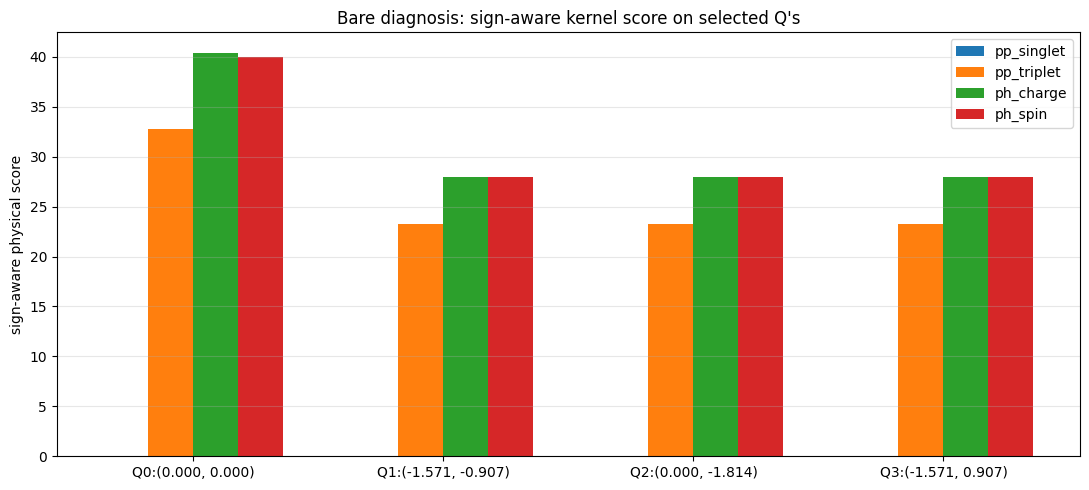


=== bare (initial) physical instability metrics ===


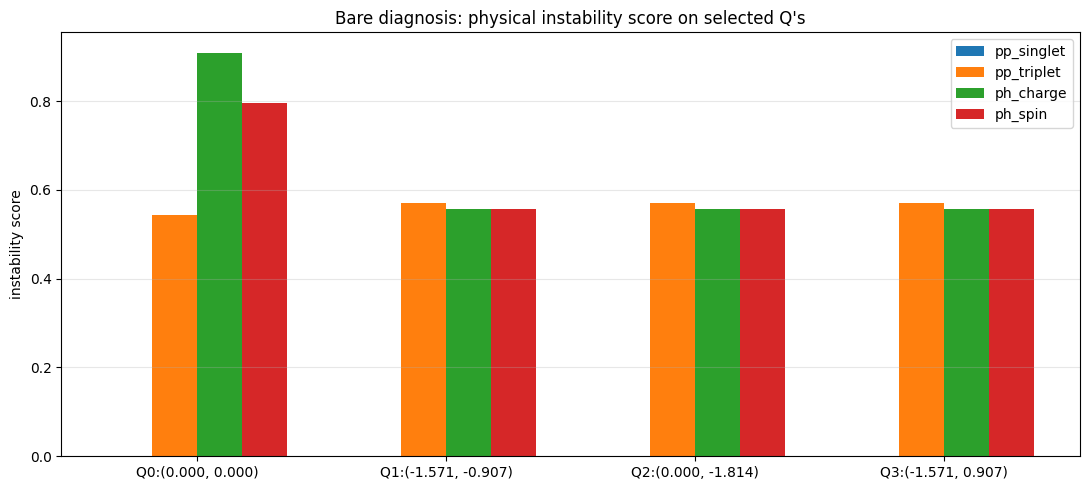

In [9]:
# ============================================================
# Choose interaction case
# ============================================================
CASE = "U_only"   # "U_only" or "V_only"

if CASE == "U_only":
    U_TEST, V_TEST = 5.0, 3.5
elif CASE == "V_only":
    U_TEST, V_TEST = 0.0, 10.0
else:
    raise ValueError("CASE must be 'U_only' or 'V_only'")


# ============================================================
# Basic diagnosis setup
# ============================================================
T_START = 2.0
T_STOP  = 0.05
NFREQ   = 50
NSTEPS  = 600

# Selected transfer momenta
M6 = patching.exact_M6_points_1bz(model)
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")


# ============================================================
# Build bare interaction + bare solver
# ============================================================
bare_int = interaction.BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = frg_flow.BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = frg_flow.FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,

    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # lenient integrator setup for exploration
    max_relative_update=5.0,
    min_substep_fraction=1.0 / 512.0,
    channel_divergence_threshold=1e10,

    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,
    diagnosis_landau_F=False,

    # current flow measure
    patch_measure_mode="length_over_vf_soft",              # change here later if needed
    patch_measure_soft_vf_eps=1e-8,
    patch_measure_normalize_mean=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())
print("solver.patch_measure_mode =", getattr(solver, "patch_measure_mode", None))

# ============================================================
# Bare sign-aware kernel metrics
# ============================================================
builder0 = build_builder_from_solver(solver, Landau_F=False)
df_signaware_bare, signaware_store = evaluate_signaware_selected_Qs(
    builder0,
    diagnosis_Qs,
    landau_F=False,
)

print("\n=== bare (initial) sign-aware kernel metrics ===")
# display(df_signaware_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_signaware_bare,
    value_col="physical_score",
    title="Bare diagnosis: sign-aware kernel score on selected Q's",
    ylabel="sign-aware physical score",
)

best_signaware_bare = leading_row_from_df(df_signaware_bare, "physical_score")
# print("\n=== bare sign-aware leader ===")
# print("channel :", best_signaware_bare["channel"])
# print("Q       :", fmt_q(best_signaware_bare["Q"], nd=6))
# print("score   :", f"{best_signaware_bare['physical_score']:.12e}")
# print("chosen  :", best_signaware_bare["chosen_sign"], f"{best_signaware_bare['chosen_eval']:.12e}")


# ============================================================
# Bare physical instability diagnosis
# ============================================================
df_instab_bare, instab_store = evaluate_instability_selected_Qs(
    builder0,
    solver,
    diagnosis_Qs,
    temperature=T_START,          # use initial T
    landau_F=False,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
)

print("\n=== bare (initial) physical instability metrics ===")
# display(df_instab_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_channel_bars(
    df_instab_bare,
    value_col="score",
    title="Bare diagnosis: physical instability score on selected Q's",
    ylabel="instability score",
)

best_instab_bare = leading_row_from_df(df_instab_bare, "score")
# print("\n=== bare physical-instability leader ===")
# print("channel :", best_instab_bare["channel"])
# print("Q       :", fmt_q(best_instab_bare["Q"], nd=6))
# print("score   :", f"{best_instab_bare['score']:.12e}")
# print("eval    :", f"{best_instab_bare['leading_eval']:.12e}")
# print("bubble  :", best_instab_bare["bubble_source"])
# print("proj    :", best_instab_bare["projection_name"])

# Flow


================ RG FLOW START ================

step=   0 | T=2.000000 | rhs_norm=0.000e+00 | lead_kernel=ph_charge @ Q0:(0.000, 0.000) score=4.043e+01
kernel scores: pp_singlet=1.038e-14, pp_triplet=3.274e+01, ph_charge=4.043e+01, ph_spin=4.000e+01
    lead_instability=ph_charge @ Q0:(0.000, 0.000) score=9.093e-01
instability: pp_singlet=4.156e-16, pp_triplet=5.431e-01, ph_charge=9.093e-01, ph_spin=7.961e-01
step=   5 | T=1.983723 | rhs_norm=3.049e+01 | lead_kernel=ph_charge @ Q0:(0.000, 0.000) score=4.028e+01
kernel scores: pp_singlet=1.433e+00, pp_triplet=3.204e+01, ph_charge=4.028e+01, ph_spin=3.913e+01
    lead_instability=ph_charge @ Q0:(0.000, 0.000) score=9.211e-01
instability: pp_singlet=3.848e-02, pp_triplet=5.396e-01, ph_charge=9.211e-01, ph_spin=7.921e-01
step=  10 | T=1.967446 | rhs_norm=2.748e+01 | lead_kernel=ph_charge @ Q0:(0.000, 0.000) score=4.019e+01
kernel scores: pp_singlet=2.749e+00, pp_triplet=3.144e+01, ph_charge=4.019e+01, ph_spin=3.831e+01
    lead_instabili

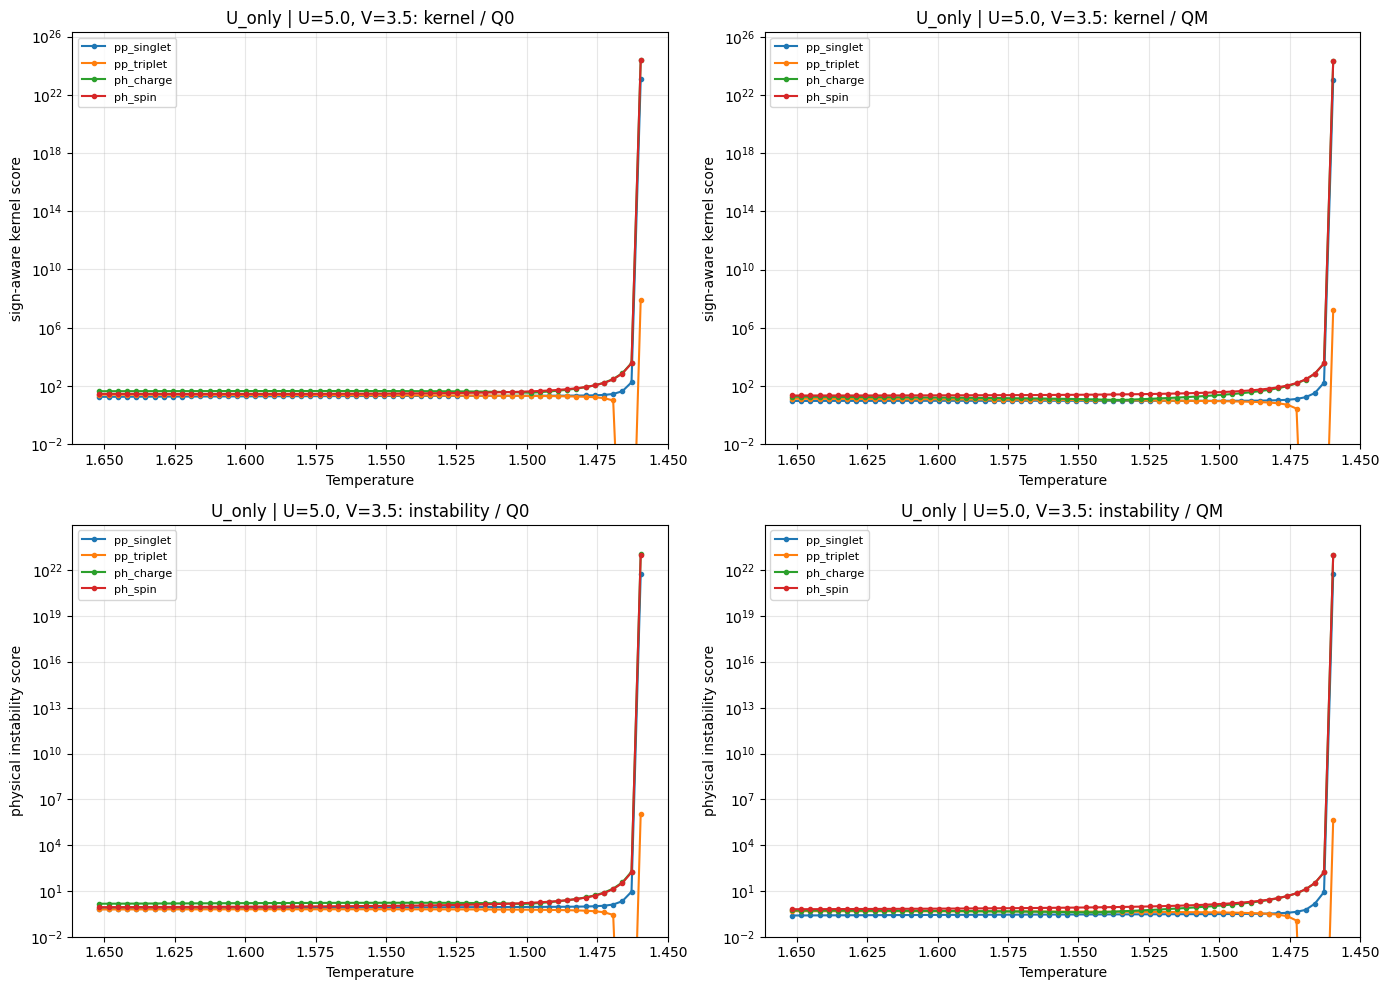

In [10]:
# ============================================================
# Flow run parameters
# ============================================================
PRINT_EVERY = 5               # print every N steps
LAST_N_STEPS_TO_PLOT = 60     # None -> plot all; integer -> only last N steps
PLOT_YLOG = True

# physical instability diagnosis options
PH_BUBBLE_MODE = "patchrep"
PROJECT_PH_CHARGE_Q0_UNIFORM = True
PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT = False


print("\n================ RG FLOW START ================\n")

# history, signaware_history_df, instability_history_df, grouped_plot_df = run_flow_with_tracking(
#     solver,
#     diagnosis_Qs,
#     print_every=PRINT_EVERY,
#     ph_bubble_mode=PH_BUBBLE_MODE,
#     project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
#     project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
# )
history, signaware_history_df, instability_history_df, grouped_plot_df, snapshots = run_flow_with_tracking_and_snapshots(
    solver,
    diagnosis_Qs,
    print_every=PRINT_EVERY,
    ph_bubble_mode=PH_BUBBLE_MODE,
    project_ph_charge_q0_uniform=PROJECT_PH_CHARGE_Q0_UNIFORM,
    project_pp_singlet_q0_local_gram_default=PROJECT_PP_SINGLET_Q0_LOCAL_GRAM_DEFAULT,
)

print("\n================ RG FLOW DONE ================\n")
print("history length =", len(history))

last_rec = history[-1]
print("final step =", last_rec.step_index)
print("final T    =", last_rec.temperature)
print("final rhs_norm =", last_rec.rhs_norm)
print("final channel_norm =", last_rec.channel_norm)
print("instability =", last_rec.instability)
print("terminated_early =", last_rec.terminated_early)
print("instability_reason =", last_rec.instability_reason)
print("termination_reason =", last_rec.termination_reason)

# display(signaware_history_df.tail(12))
# display(instability_history_df.tail(12))

plot_flow_group_curves(
    grouped_plot_df,
    last_n_steps=LAST_N_STEPS_TO_PLOT,
    ylog=PLOT_YLOG,
    title_prefix=f"{CASE} | U={U_TEST}, V={V_TEST}",
    ylim=1e-2
)

# Diagnosis

## Particle-Particle vs Particle-Hole

Diagnosing step_index = 157
T = 1.488898
rhs_norm = 1.655e+03
channel_norm = 4.113e+01
instability = False
terminated_early = False
instability_reason = None
termination_reason = None

=== sign-aware leader at selected step ===
channel : ph_spin
Q       : (0.000000, 0.000000)
score   : 5.380999666715e+01
chosen  : negative -5.380999666715e+01

=== physical-instability leader at selected step ===
channel : ph_spin
Q       : (0.000000, 0.000000)
score   : 2.185935413630e+00
eval    : 2.185935413630e+00
bubble  : patchrep:bubble_dot_ph(eps_p,eps_p+Q)*measure_p
proj    : nan


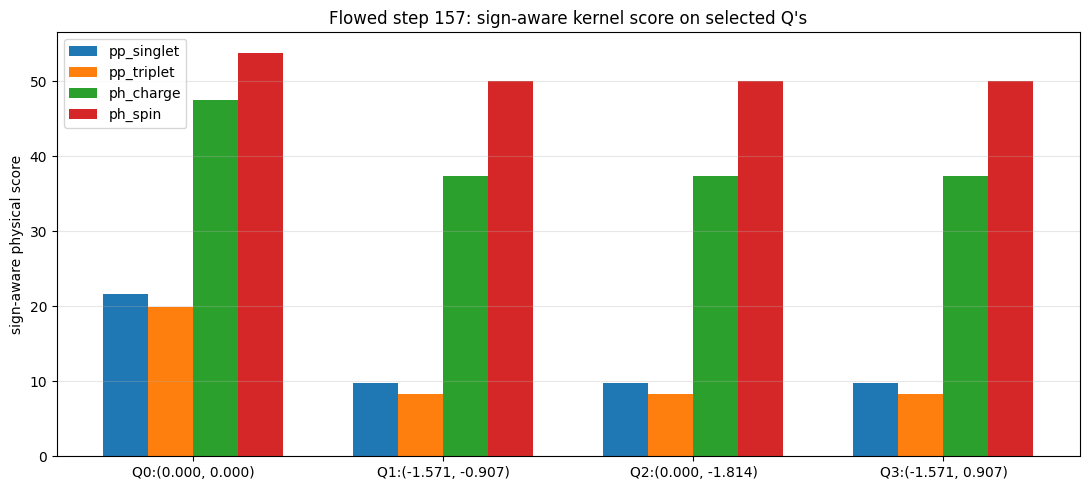

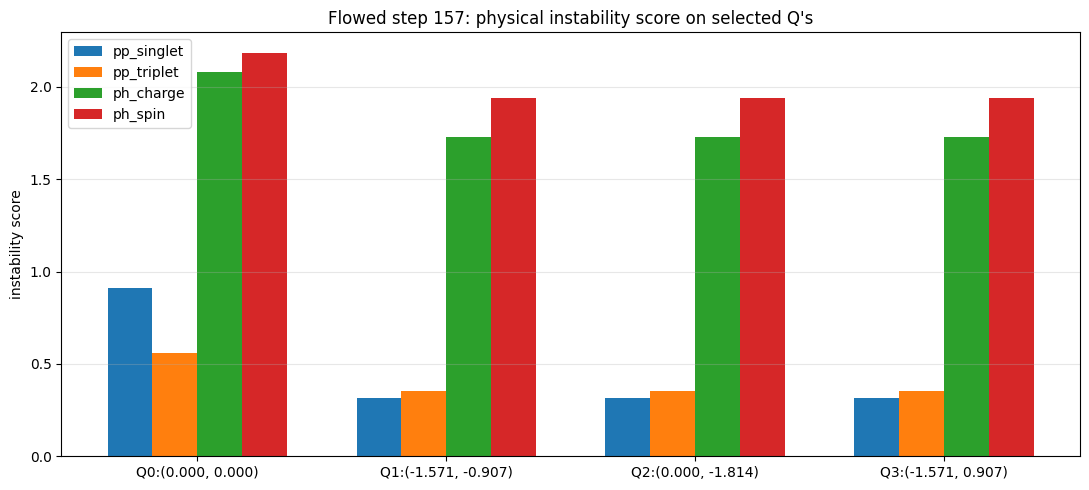

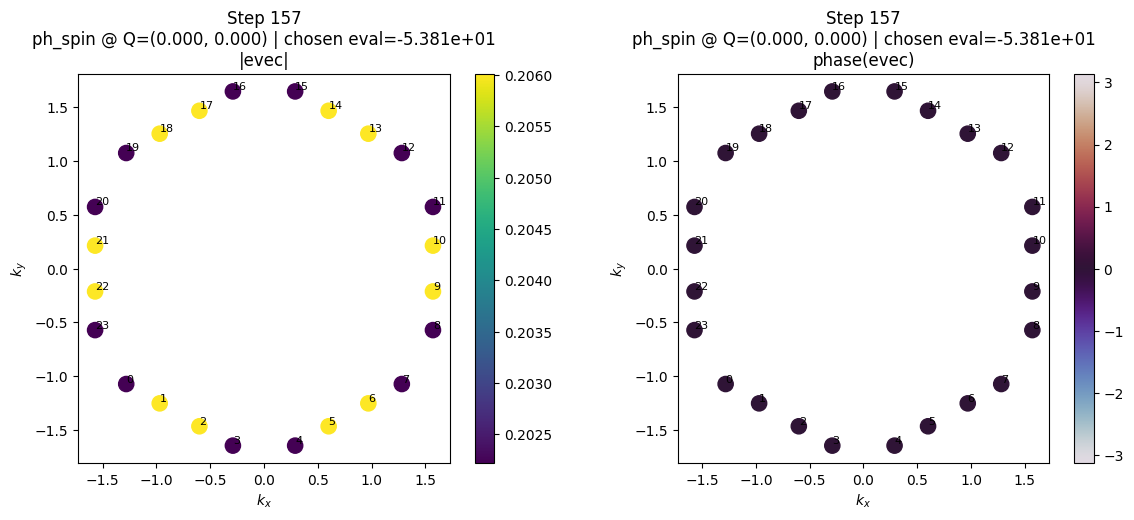

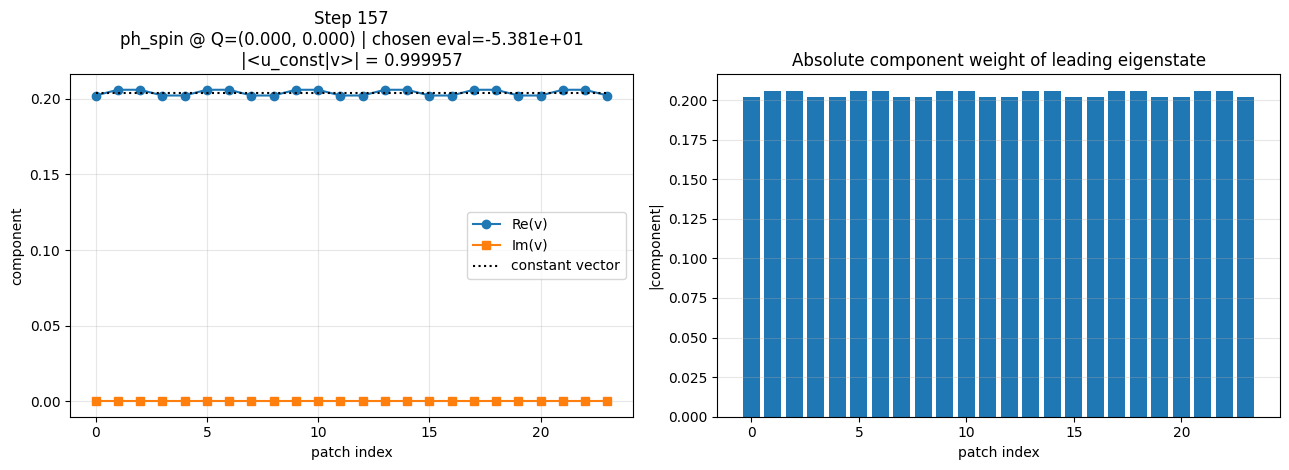


=== leader eigenstate summary ===
channel            : ph_spin
Q                  : (0.000000, 0.000000)
selected eigenvalue: -5.380999666715e+01
kernel dimension   : 24
|<u_const|v>|      : 9.999567839862e-01


In [14]:
# ============================================================
# Diagnose one flowed step
# ============================================================
STEP_SELECTOR = -10   # -1 last step, -2 second last, -3 third last, or exact step index

diagnosis_result = diagnose_flowed_step(
    solver,
    history,
    diagnosis_Qs,
    step_selector=STEP_SELECTOR,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
    plot_eigenstate=True,
)
# Optional: inspect the raw tables
# display(diagnosis_result["df_signaware"].sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(diagnosis_result["df_instability"].sort_values(["Q_index", "channel"]).reset_index(drop=True))

## Order

,step_index,T,Q_M_used_for_cBO_sBO,FM_projected_score,FM_overlap_with_current_leader,FM_true_leading_score,PI_projected_score,PI_overlap_with_current_leader,PI_true_leading_score,cBO_projected_score,cBO_overlap_with_current_leader,cBO_true_leading_score,sBO_projected_score,sBO_overlap_with_current_leader,sBO_true_leading_score
0,165,1.462855,[-1.570796 0.9069 ],127.42962,0.502146,166.253165,-128.354926,8.279850e-33,184.412271,6.96019,1.090570e-28,164.661497,77.867942,0.29534,166.157291


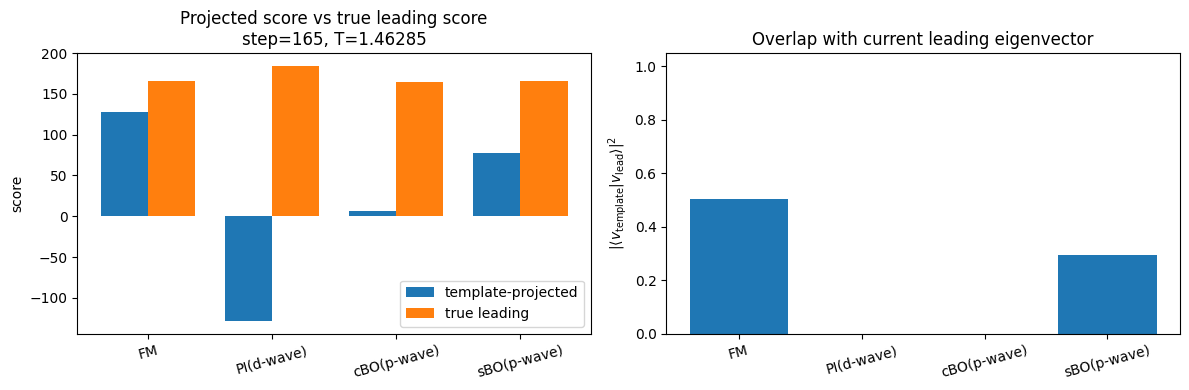

In [24]:
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
SHOW_PATCH_PLOTS = True
SHOW_TRUE_LEADER_COMPARISON = True
STEP_SELECTOR = -2
M_TEMPLATE_CHOICE = "best"
selected_rec, selected_snap = _resolve_snapshot_and_record(history, snapshots, STEP_SELECTOR)

# -------------------------------
# Resolve Q list
# -------------------------------
if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

Q0_list = [q for q in diag_Qs if _allclose_zero(q)]
QM_list = [q for q in diag_Qs if not _allclose_zero(q)]

if len(Q0_list) != 1:
    raise ValueError(f"Expected exactly one Q=0 in diagnosis_Qs, found {len(Q0_list)}")
if len(QM_list) == 0:
    raise ValueError("Need at least one finite-Q candidate in diagnosis_Qs.")

Q0 = Q0_list[0]

# -------------------------------
# Prepare selected step / templates
# -------------------------------
instability_cfg = _default_instability_config_from_solver(solver)
patchset_up = solver.patchsets["up"] if "up" in solver.patchsets else list(solver.patchsets.values())[0]

templates = _build_harmonic_templates_from_patchset(patchset_up)
template_FM = templates["FM_L0"]
basis_P = templates["P_L1_basis"]   # for cBO / sBO
basis_D = templates["D_L2_basis"]   # for PI

# -------------------------------
# Build selected-step channel kernels
# -------------------------------
kdict_Q0, idict_Q0 = _build_kernel_and_instability_dict(
    solver, Q0, instability_cfg,
    snapshot=selected_snap,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD
)

# choose finite-Q for cBO/sBO
if M_TEMPLATE_CHOICE == "best":
    best_score = None
    Q_best = None
    best_pack = None
    for Qm in QM_list:
        kdict_m, idict_m = _build_kernel_and_instability_dict(
            solver, Qm, instability_cfg,
            snapshot=selected_snap,
            Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD
        )
        score_c = float(idict_m["ph_charge"].score_unprojected)
        score_s = float(idict_m["ph_spin"].score_unprojected)
        score = max(score_c, score_s)
        if (best_score is None) or (score > best_score):
            best_score = score
            Q_best = np.asarray(Qm, dtype=float)
            best_pack = (kdict_m, idict_m)
    Q_M = Q_best
    kdict_M, idict_M = best_pack
else:
    Q_M = np.asarray(QM_list[int(M_TEMPLATE_CHOICE)], dtype=float)
    kdict_M, idict_M = _build_kernel_and_instability_dict(
        solver, Q_M, instability_cfg,
        snapshot=selected_snap,
        Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD
    )

# -------------------------------
# Evaluate FM on Q=0 ph_spin
# -------------------------------
fm_eval = _evaluate_template_component(
    solver, Q0, "ph_spin", template_FM, instability_cfg,
    snapshot=selected_snap,
    use_operator=USE_BUBBLE_DRESSED_OPERATOR,
    Landau_F_for_channel_build=Landau_F_FOR_CHANNEL_BUILD
)

# -------------------------------
# Evaluate PI on Q=0 ph_charge using true D-wave subspace
# -------------------------------
pi_op = idict_Q0["ph_charge"].operator_unprojected if (
    USE_BUBBLE_DRESSED_OPERATOR and idict_Q0["ph_charge"].operator_unprojected is not None
) else _hermitian(kdict_Q0["ph_charge"].matrix)

PI_projected_score, template_PI = _best_score_in_subspace(pi_op, basis_D)
PI_overlap = _overlap2(template_PI, idict_Q0["ph_charge"].leading_evec)
PI_true_leading_score = float(idict_Q0["ph_charge"].score_unprojected)
PI_current_leader = _normalize_vec(idict_Q0["ph_charge"].leading_evec)

# -------------------------------
# Evaluate cBO on Q=M ph_charge using true P-wave subspace
# -------------------------------
cbo_op = idict_M["ph_charge"].operator_unprojected if (
    USE_BUBBLE_DRESSED_OPERATOR and idict_M["ph_charge"].operator_unprojected is not None
) else _hermitian(kdict_M["ph_charge"].matrix)

cBO_projected_score, template_cBO = _best_score_in_subspace(cbo_op, basis_P)
cBO_overlap = _overlap2(template_cBO, idict_M["ph_charge"].leading_evec)
cBO_true_leading_score = float(idict_M["ph_charge"].score_unprojected)
cBO_current_leader = _normalize_vec(idict_M["ph_charge"].leading_evec)

# -------------------------------
# Evaluate sBO on Q=M ph_spin using true P-wave subspace
# -------------------------------
sbo_op = idict_M["ph_spin"].operator_unprojected if (
    USE_BUBBLE_DRESSED_OPERATOR and idict_M["ph_spin"].operator_unprojected is not None
) else _hermitian(kdict_M["ph_spin"].matrix)

sBO_projected_score, template_sBO = _best_score_in_subspace(sbo_op, basis_P)
sBO_overlap = _overlap2(template_sBO, idict_M["ph_spin"].leading_evec)
sBO_true_leading_score = float(idict_M["ph_spin"].score_unprojected)
sBO_current_leader = _normalize_vec(idict_M["ph_spin"].leading_evec)

# -------------------------------
# Summary table
# -------------------------------
df_projected_modes_current = pd.DataFrame([{
    "step_index": int(selected_rec.step_index),
    "T": float(selected_snap.T),
    "Q_M_used_for_cBO_sBO": np.array2string(Q_M, precision=6),

    "FM_projected_score": fm_eval["projected_score"],
    "FM_overlap_with_current_leader": fm_eval["overlap_with_current_leader"],
    "FM_true_leading_score": fm_eval["true_leading_score"],

    "PI_projected_score": PI_projected_score,
    "PI_overlap_with_current_leader": PI_overlap,
    "PI_true_leading_score": PI_true_leading_score,

    "cBO_projected_score": cBO_projected_score,
    "cBO_overlap_with_current_leader": cBO_overlap,
    "cBO_true_leading_score": cBO_true_leading_score,

    "sBO_projected_score": sBO_projected_score,
    "sBO_overlap_with_current_leader": sBO_overlap,
    "sBO_true_leading_score": sBO_true_leading_score,
}])

display(df_projected_modes_current)

# -------------------------------
# Summary plots (SIMPLIFIED 2-PANEL VERSION)
# -------------------------------
labels = ["FM", "PI(d-wave)", "cBO(p-wave)", "sBO(p-wave)"]

projected_scores = [
    fm_eval["projected_score"],
    PI_projected_score,
    cBO_projected_score,
    sBO_projected_score,
]

true_leading_scores = [
    fm_eval["true_leading_score"],
    PI_true_leading_score,
    cBO_true_leading_score,
    sBO_true_leading_score,
]

overlaps = [
    fm_eval["overlap_with_current_leader"],
    PI_overlap,
    cBO_overlap,
    sBO_overlap,
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------------------------------
# Left: projected vs true leading
# ---------------------------------
x = np.arange(len(labels))
w = 0.38

axes[0].bar(
    x - w/2,
    projected_scores,
    width=w,
    label="template-projected"
)

axes[0].bar(
    x + w/2,
    true_leading_scores,
    width=w,
    label="true leading"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15)

axes[0].set_title(
    f"Projected score vs true leading score\n"
    f"step={int(selected_rec.step_index)}, T={selected_snap.T:.6g}"
)

axes[0].set_ylabel("score")
axes[0].legend()

# ---------------------------------
# Right: overlap
# ---------------------------------
axes[1].bar(labels, overlaps)

axes[1].set_ylim(0, 1.05)

axes[1].set_title("Overlap with current leading eigenvector")

axes[1].set_ylabel(
    r"$|\langle v_{\rm template}|v_{\rm lead}\rangle|^2$"
)

axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Comparison

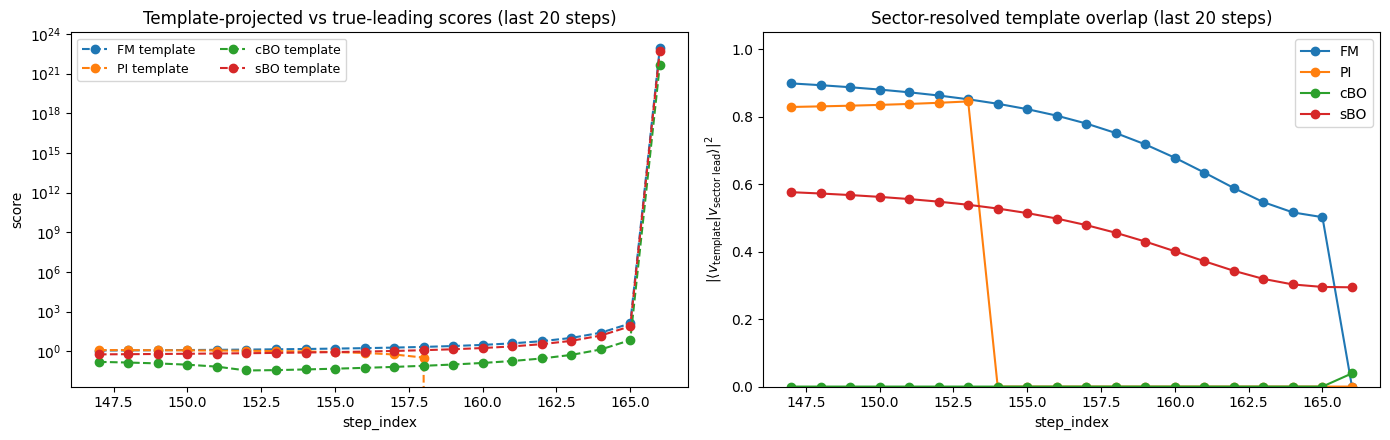

In [31]:
# ============================================================
# Last-20-step line plots for projected diagnosis
# ============================================================

# -------------------------------
# User controls
# -------------------------------
LAST_N_STEPS = 20
USE_BUBBLE_DRESSED_OPERATOR = True
Landau_F_FOR_CHANNEL_BUILD = False
M_TEMPLATE_CHOICE = "best"   # or explicit finite-Q index, e.g. 0, 1, 2
X_AXIS = "step_index"        # "step_index" or "T"

# -------------------------------
# Resolve Q list
# -------------------------------
if "diagnosis_Qs" in globals() and diagnosis_Qs is not None:
    diag_Qs = [np.asarray(q, dtype=float) for q in diagnosis_Qs]
else:
    diag_Qs = [np.asarray(q, dtype=float) for q in solver.diagnosis_Qs]

# -------------------------------
# Build time series
# -------------------------------
df_projected_modes_ts = collect_projected_mode_timeseries(
    solver,
    history,
    snapshots,
    diagnosis_Qs=diag_Qs,
    last_n_steps=LAST_N_STEPS,
    M_TEMPLATE_CHOICE=M_TEMPLATE_CHOICE,
    USE_BUBBLE_DRESSED_OPERATOR=USE_BUBBLE_DRESSED_OPERATOR,
    Landau_F_FOR_CHANNEL_BUILD=Landau_F_FOR_CHANNEL_BUILD,
)

# display(df_projected_modes_ts)

# -------------------------------
# Plot
# -------------------------------
plot_projected_mode_timeseries(
    df_projected_modes_ts,
    x_axis=X_AXIS,
    title_suffix=f" (last {LAST_N_STEPS} steps)", plot_all=False
)

# Debug

## Patch Information

In [ ]:

# # ------------------------------------------------------------
# # print patch info: k, energy, vF, |vF|, l, l/|vF|
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     ps = patchsets[spin]
#     print(f"\n{'='*72}")
#     print(f"{spin} patchset summary")
#     print(f"{'='*72}")
#     print(f"Npatch            = {ps.Npatch}")
#     print(f"gauge_method      = {ps.gauge_method}")
#     print(f"gauge_loop_phase  = {ps.gauge_loop_phase:.12e}")
#     print()

#     for p in ps.patches:
#         print(
#             f"id={p.patch_id:2d} | "
#             f"k={np.round(p.k_cart, 8)} | "
#             f"k_red={np.round(p.k_red, 8)} | "
#             f"E={p.energy:+.12e} | "
#             f"vF={np.round(p.vF, 8)} | "
#             f"|vF|={p.vF_norm:.12e} | "
#             f"l={0.0 if p.fs_arc_length is None else p.fs_arc_length:.12e} | "
#             f"l/|vF|={0.0 if p.weight_length_over_vf is None else p.weight_length_over_vf:.12e}"
#         )

# # ------------------------------------------------------------
# # gauge smoothness / loop phase check
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)

#     ovs = []
#     for i in range(len(U)):
#         j = (i + 1) % len(U)
#         ovs.append(np.vdot(U[i], U[j]))
#     ovs = np.asarray(ovs, dtype=complex)

#     print(f"\n{'='*72}")
#     print(f"{spin} gauge smoothness check")
#     print(f"{'='*72}")
#     print("neighbor overlap abs =")
#     print(np.round(np.abs(ovs), 8))
#     print("neighbor overlap arg =")
#     print(np.round(np.angle(ovs), 8))

#     # loop closure overlap
#     if len(U) > 1:
#         loop_ov = np.vdot(U[-1], U[0])
#         print(f"last-first overlap abs = {abs(loop_ov):.12e}")
#         print(f"last-first overlap arg = {np.angle(loop_ov):.12e}")

#     # whether the stored loop phase is basically fixed
#     if abs(patchsets[spin].gauge_loop_phase) < 1e-8:
#         print("Gauge loop phase looks fixed: YES")
#     else:
#         print("Gauge loop phase looks fixed: NOT fully")

# # ------------------------------------------------------------
# # compact arrays for later reuse
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     ps = patchsets[spin]
#     print(f"\n{'='*72}")
#     print(f"{spin} compact arrays")
#     print(f"{'='*72}")
#     print("energies =")
#     print(np.array2string(ps.patch_energy, precision=10, suppress_small=False))
#     print("vF norms =")
#     print(np.array2string(ps.patch_vF_norm, precision=10, suppress_small=False))
#     print("arc lengths l =")
#     print(np.array2string(ps.patch_arc_length, precision=10, suppress_small=False))
#     print("l / |vF| =")
#     print(np.array2string(ps.patch_weight_length_over_vf, precision=10, suppress_small=False))

# # ------------------------------------------------------------
# # extra strict sanity checks
# # ------------------------------------------------------------
# for spin in ["up", "dn"]:
#     ps = patchsets[spin]
#     max_abs_E = np.max(np.abs(ps.patch_energy)) if ps.Npatch > 0 else 0.0
#     print(f"\n{spin}: max |E-mu| = {max_abs_E:.12e}")